In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Estadística
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import AnovaRM
import pingouin as pg

# Configuración de plots
#!matplotlib inline
sns.set(font_scale=1.3, style='ticks')
plt.rcParams['figure.dpi'] = 100

print('librerias OK')

Traceback (most recent call last):
  File "/opt/anaconda3/envs/SINTESI/bin/matplotlib", line 11, in <module>
    sys.exit(plotting._matplotlib())
AttributeError: module 'pandas.plotting' has no attribute '_matplotlib'
librerias OK


In [2]:
def RT_filter(x, sd):
    """
    Filtra trials con RT superior a 'sd' desviaciones estándar respecto
    a la media del participante. Se aplica por participante (groupby),
    no sobre el total del dataset.
    """
    rt_mean = x['RT'].mean()
    up_lim  = rt_mean + sd * x['RT'].std()
    return x[x['RT'] < up_lim]

In [3]:
def log_reg_fit(x, f):
    """
    Ajusta un modelo de regresión logística (GLM binomial) y extrae:
    - intercept : término independiente
    - weight    : pendiente, sensibilidad al estímulo (rDV)
    - PSE       : -intercept/weight → valor de rDV donde p(diagonal) = 0.5

    Se usará con groupby().apply() para obtener parámetros por participante.
    """
    reg       = smf.glm(formula=f, data=x, family=sm.families.Binomial()).fit()
    intercept = reg.params['Intercept']
    weight    = reg.params['rDV']
    PSE       = -intercept / weight
    return pd.DataFrame([[intercept, weight, PSE]],
                        columns=['intercept', 'weight', 'PSE'])

In [4]:
def switch_strategy(data):
    """
    Calcula el índice de 'stubbornness' (terquedad):
    la probabilidad de NO cambiar de decisión después de haber fallado.

    - phit       : p(switch | error)   → cambia tras equivocarse
    - pfa        : p(switch | acierto) → cambia tras acertar
    - stuborness : 1 - phit            → terquedad (no cambiar tras error)
    """
    dfwrong = data[data['correct-1'] == 0]['switch']
    dfwrong.reset_index(drop=True, inplace=True)
    phit = dfwrong.mean()
    if phit == 0:
        phit = 0.0001  # evitar división por cero

    dfright = data[data['correct-1'] == 1]['switch']
    dfright.reset_index(drop=True, inplace=True)
    pfa = dfright.mean()
    if pfa == 0:
        pfa = 0.0001

    stuborness = 1 - phit
    return pd.DataFrame([[phit, pfa, stuborness]],
                        columns=['phit', 'pfa', 'stuborness'])

In [5]:

data_path = '/Users/martu/Documents/TFG_MARTINA/dataset/CJ_EEG.csv'  

all_df = pd.read_csv(data_path)
print(f'Dataset cargado: {all_df.shape[0]} filas, {all_df.shape[1]} columnas')
all_df.head(3)

Dataset cargado: 6600 filas, 36 columnas


,exp_ID,npar,subj,nblock,ntrial,nrep,cond-1,trial_type,rDV,deci-3,...,d6,o1,o2,o3,o4,o5,o6,metad,metad_3%,metad_97%
0,CJ_EEG,1,s01,0,0,0,0,repeat,-0.203974,0,...,-0.944496,2.697,0.715,1.903,1.576,1.214,1.549,0.086,-0.345,0.51
1,CJ_EEG,1,s01,0,0,1,0,repeat,-0.203974,0,...,-0.944496,2.697,0.715,1.903,1.576,1.214,1.549,0.086,-0.345,0.51
2,CJ_EEG,1,s01,0,0,2,0,repeat,-0.203974,0,...,-0.944496,2.697,0.715,1.903,1.576,1.214,1.549,0.086,-0.345,0.51


In [6]:
df = all_df.copy()  # siempre trabajar sobre una copia

# Recodificación por si acaso (en nuestro CSV ya deberían ser 0/1)
df['cond']    = df['cond'].replace([-1], 0)
df['correct'] = df['correct'].replace([-1], 0)

# 'switch': 1 si cambió de decisión respecto al nrep anterior, 0 si la mantuvo
# Solo tiene sentido para nrep > 0
df['switch'] = 1
df.loc[df['deci'] == df['deci-1'], 'switch'] = 0

# 'conf_lvl': confianza binarizada en Alta (H) y Baja (L) usando la mediana
median_confi = df['confi'].median()
df['conf_lvl'] = 'L'
df.loc[df['confi'] >= median_confi, 'conf_lvl'] = 'H'

# Verificación
print(f"cond     → {sorted(df['cond'].unique())}")
print(f"correct  → {sorted(df['correct'].unique())}")
print(f"switch   → {sorted(df['switch'].unique())}")
print(f"conf_lvl → {sorted(df['conf_lvl'].unique())}")
print(f"nrep     → {sorted(df['nrep'].unique())}")
print(f"trial_type → {sorted(df['trial_type'].unique())}")
print(f"\nParticipantes: {sorted(df['subj'].unique())}")
print(f"Total filas: {len(df)}")

cond     → [np.int64(0), np.int64(1)]
correct  → [np.int64(0), np.int64(1)]
switch   → [np.int64(0), np.int64(1)]
conf_lvl → ['H', 'L']
nrep     → [np.int64(0), np.int64(1), np.int64(2)]
trial_type → ['nonrepeat', 'repeat']

Participantes: ['S03', 's01', 's04', 's05', 's07', 's08', 's09', 's10', 's11', 's12', 's13', 's14', 's15', 's16', 's17', 's18', 's19', 's20', 's21', 's22', 's23', 's24', 's25', 's26', 's27']
Total filas: 6600


In [7]:
# Comprobación de nulos
nulos = df.isnull().sum()
print('Columnas con valores nulos:')
print(nulos[nulos > 0])
# Los nulos en metad son normales: es un valor único por participante

Columnas con valores nulos:
metad        264
metad_3%     264
metad_97%    264
dtype: int64


In [8]:
# Aplicamos el filtro por participante (groupby npar)
# sd=4 significa: eliminamos trials con RT > media + 4*std del participante
df_rt = df.groupby(['npar'], group_keys=False).apply(RT_filter, sd=4)

filas_antes  = len(df)
filas_despues = len(df_rt)
print(f'Trials antes del filtro : {filas_antes}')
print(f'Trials después del filtro: {filas_despues}')
print(f'Trials eliminados        : {filas_antes - filas_despues} ({(filas_antes - filas_despues)/filas_antes*100:.1f}%)')

Trials antes del filtro : 6600
Trials después del filtro: 6537
Trials eliminados        : 63 (1.0%)


/var/folders/6t/135j38t15hx5h_82vyspq6pm0000gn/T/ipykernel_69427/1030162169.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_rt = df.groupby(['npar'], group_keys=False).apply(RT_filter, sd=4)


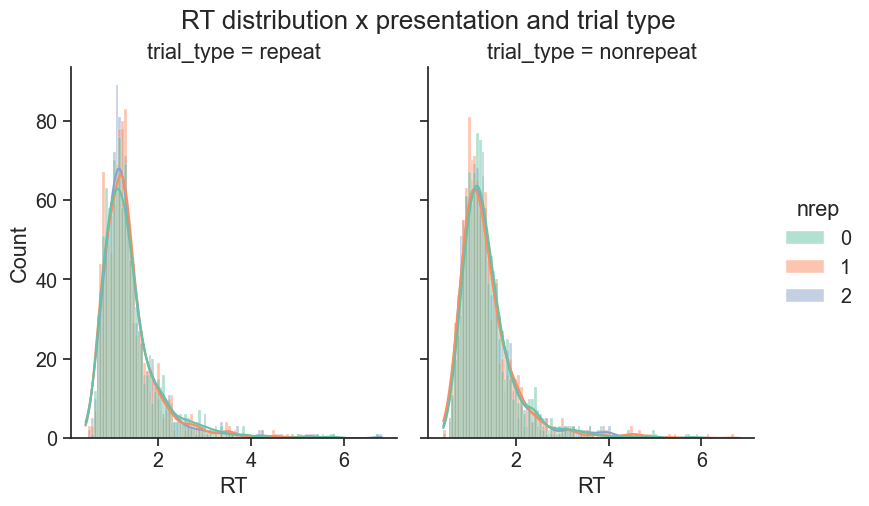

In [9]:
# Separado por trial_type (repeat vs nonrepeat), coloreado por nrep
sns.displot(
    data=df_rt,
    x='RT',
    hue='nrep',
    col='trial_type',
    height=5,
    aspect=0.8,
    kind='hist',
    kde=True,
    palette='Set2'
)
plt.suptitle('RT distribution x presentation and trial type', y=1.02)
plt.show()

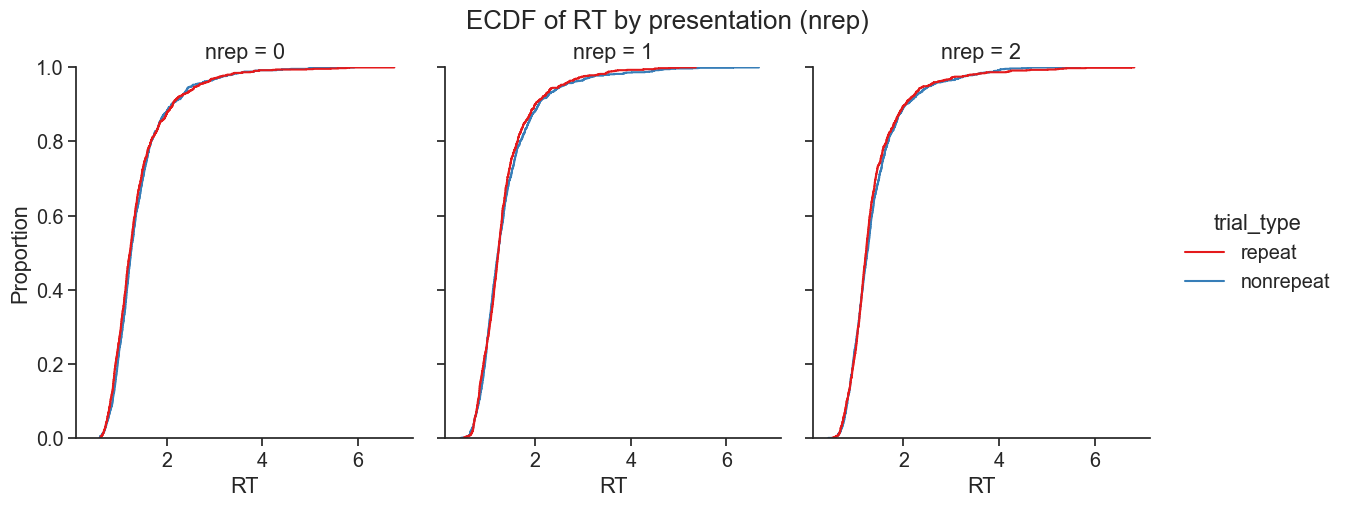

In [10]:
# La curva ECDF muestra qué proporción de trials tienen RT menor a cada valor
# Útil para ver si hay diferencias sistemáticas entre nrep o trial_type
sns.displot(
    data=df_rt,
    x='RT',
    hue='trial_type',
    col='nrep',
    height=5,
    aspect=0.8,
    kind='ecdf',
    palette='Set1'
)
plt.suptitle('ECDF of RT by presentation (nrep)', y=1.02)
plt.show()

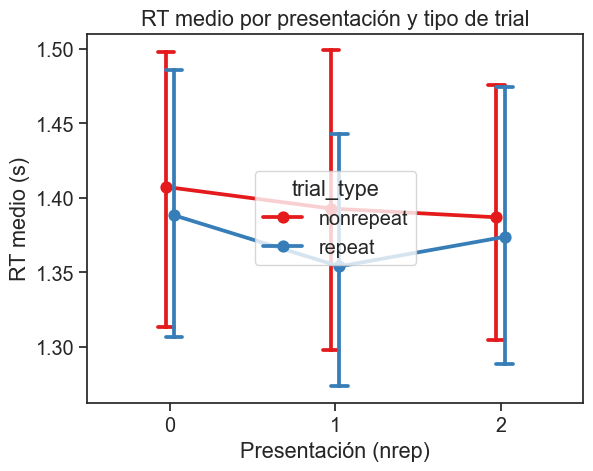


ANOVA de medidas repetidas — RT:


,Source,SS,ddof1,ddof2,MS,F,p_unc,p_GG_corr,ng2,eps
0,nrep,0.015881,2,48,0.007941,0.760550,0.472958,0.465558,0.001953,0.938157
1,trial_type,0.021077,1,24,0.021077,4.968846,0.035429,0.035429,0.002591,1.000000
2,nrep * trial_type,0.004530,2,48,0.002265,0.304661,0.738789,0.728074,0.000558,0.951419


In [11]:
# Calculamos el RT medio por participante, nrep y trial_type
# Esto nos permite ver si el RT cambia con las repeticiones (señal de aprendizaje o fatiga)
avg_rt = df_rt.groupby(['subj', 'nrep', 'trial_type'], as_index=False)[['RT']].mean()

sns.pointplot(
    data=avg_rt,
    x='nrep',
    y='RT',
    hue='trial_type',
    dodge=True,
    capsize=0.1,
    palette='Set1'
)
plt.xlabel('Presentación (nrep)')
plt.ylabel('RT medio (s)')
plt.title('RT medio por presentación y tipo de trial')
plt.show()

# Estadística: ¿hay diferencias significativas en RT entre nrep y trial_type?
print('\nANOVA de medidas repetidas — RT:')
pg.rm_anova(dv='RT', within=['nrep', 'trial_type'], subject='subj',
            data=avg_rt, detailed=True, correction=True)

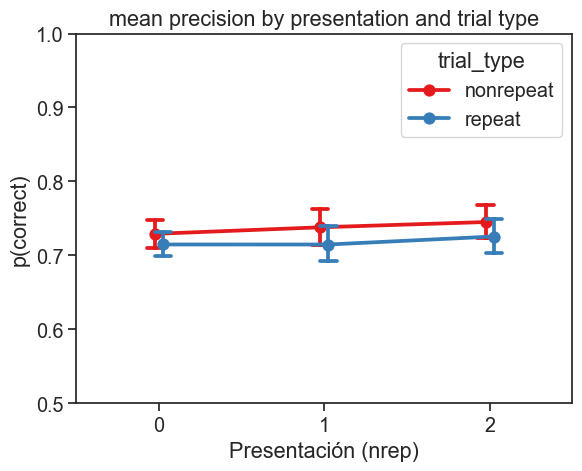

In [12]:
# Precisión media por participante, nrep y trial_type
avg_correct = df_rt.groupby(['subj', 'nrep', 'trial_type'], as_index=False)[['correct']].mean()

sns.pointplot(
    data=avg_correct,
    x='nrep',
    y='correct',
    hue='trial_type',
    dodge=True,
    capsize=0.1,
    palette='Set1'
)
plt.xlabel('Presentación (nrep)')
plt.ylabel('p(correct)')
plt.title('mean precision by presentation and trial type')
plt.ylim(0.5, 1.0)
plt.show()

In [13]:
print('ANOVA de medidas repetidas — Precisión:')
pg.rm_anova(
    dv='correct',
    within=['nrep', 'trial_type'],
    subject='subj',
    data=avg_correct,
    detailed=True,
    correction=True
)

ANOVA de medidas repetidas — Precisión:


,Source,SS,ddof1,ddof2,MS,F,p_unc,p_GG_corr,ng2,eps
0,nrep,0.004650,2,48,0.002325,1.006835,0.372958,0.368249,0.009858,0.924794
1,trial_type,0.013649,1,24,0.013649,2.359494,0.137602,0.137602,0.028393,1.000000
2,nrep * trial_type,0.000498,2,48,0.000249,0.159866,0.852710,0.849086,0.001065,0.982139


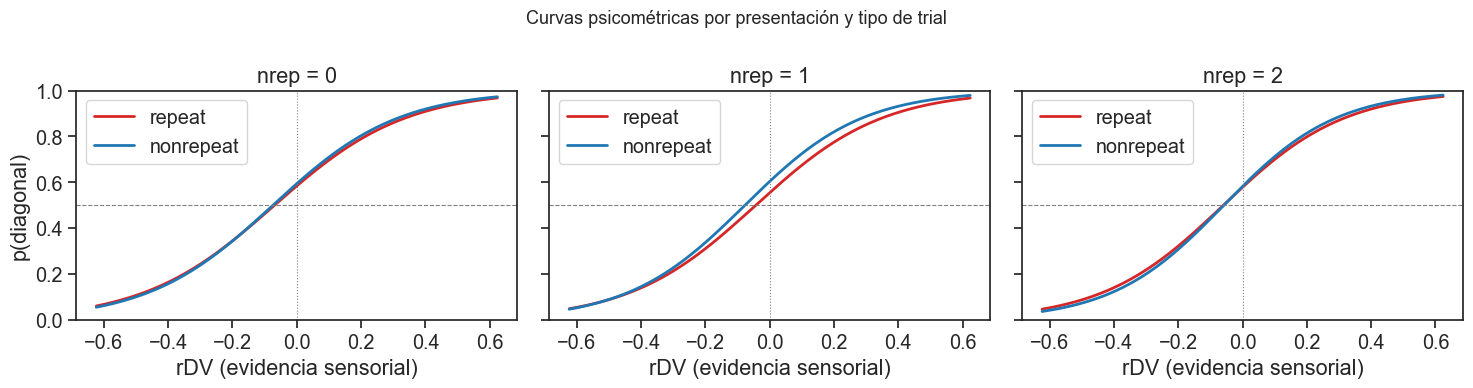

In [14]:
# ── CURVAS PSICOMÉTRICAS por nrep y trial_type ──────────────────────────────
import scipy.special as sps

rdv_range = np.linspace(df_rt['rDV'].min(), df_rt['rDV'].max(), 200)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, nrep_val in zip(axes, [0, 1, 2]):
    subset = df_rt[df_rt['nrep'] == nrep_val]
    
    for tt, color in zip(['repeat', 'nonrepeat'], ['tab:red', 'tab:blue']):
        data_tt = subset[subset['trial_type'] == tt]
        
        # Ajuste logístico
        reg = smf.glm('deci ~ rDV', data=data_tt,
                      family=sm.families.Binomial()).fit()
        
        # Curva predicha
        y_pred = sps.expit(reg.params['Intercept'] + reg.params['rDV'] * rdv_range)
        
        ax.plot(rdv_range, y_pred, color=color, label=tt, linewidth=2)
    
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
    ax.axvline(0.0, color='gray', linestyle=':', linewidth=0.8)
    ax.set_title(f'nrep = {nrep_val}')
    ax.set_xlabel('rDV (evidencia sensorial)')
    ax.set_ylabel('p(diagonal)' if nrep_val == 0 else '')
    ax.set_ylim(0, 1)
    ax.legend()

plt.suptitle('Curvas psicométricas por presentación y tipo de trial', fontsize=13)
plt.tight_layout()
plt.show()

In [15]:
# Ajustamos la regresión logística deci ~ rDV por participante, nrep y trial_type
# Usamos df_rt (ya filtrado de outliers de RT)
formula = 'deci ~ rDV'
log_reg_nrep = df_rt.groupby(['subj', 'nrep', 'trial_type']).apply(log_reg_fit, formula)
log_reg_nrep.reset_index(inplace=True)
log_reg_nrep.drop(columns='level_3', errors='ignore', inplace=True)
print(log_reg_nrep.head(6))

  subj  nrep trial_type  intercept    weight       PSE
0  S03     0  nonrepeat   1.180302  5.832419 -0.202369
1  S03     0     repeat   1.088192  7.483183 -0.145418
2  S03     1  nonrepeat   1.185358  9.552448 -0.124089
3  S03     1     repeat   0.572640  7.104382 -0.080604
4  S03     2  nonrepeat   0.937739  4.549234 -0.206131
5  S03     2     repeat   1.423058  8.940153 -0.159176


/var/folders/6t/135j38t15hx5h_82vyspq6pm0000gn/T/ipykernel_69427/3568916361.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  log_reg_nrep = df_rt.groupby(['subj', 'nrep', 'trial_type']).apply(log_reg_fit, formula)


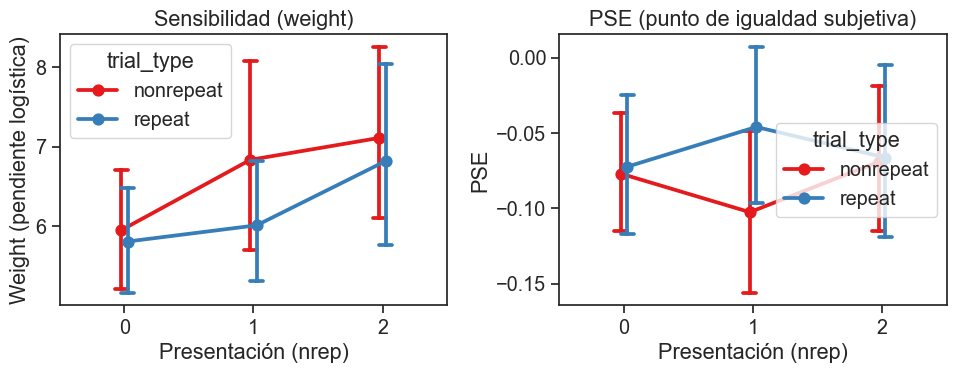

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Weight (sensibilidad al estímulo)
sns.pointplot(
    data=log_reg_nrep,
    x='nrep',
    y='weight',
    hue='trial_type',
    dodge=True,
    capsize=0.1,
    palette='Set1',
    ax=axes[0]
)
axes[0].set_title('Sensibilidad (weight)')
axes[0].set_xlabel('Presentación (nrep)')
axes[0].set_ylabel('Weight (pendiente logística)')

# PSE (punto de igualdad subjetiva)
sns.pointplot(
    data=log_reg_nrep,
    x='nrep',
    y='PSE',
    hue='trial_type',
    dodge=True,
    capsize=0.1,
    palette='Set1',
    ax=axes[1]
)
axes[1].set_title('PSE (punto de igualdad subjetiva)')
axes[1].set_xlabel('Presentación (nrep)')
axes[1].set_ylabel('PSE')

plt.tight_layout()
plt.show()

In [17]:
# ¿La sensibilidad al estímulo cambia con las repeticiones o el tipo de trial?
print('ANOVA — Weight:')
print(pg.rm_anova(
    dv='weight',
    within=['nrep', 'trial_type'],
    subject='subj',
    data=log_reg_nrep,
    detailed=True,
    correction=True
))

print('\nANOVA — PSE:')
print(pg.rm_anova(
    dv='PSE',
    within=['nrep', 'trial_type'],
    subject='subj',
    data=log_reg_nrep,
    detailed=True,
    correction=True
))

ANOVA — Weight:
              Source         SS  ddof1  ddof2         MS         F     p_unc  \
0               nrep  29.375285      2     48  14.687643  4.839441  0.012173   
1         trial_type   6.531766      1     24   6.531766  0.632592  0.434202   
2  nrep * trial_type   3.189370      2     48   1.594685  0.712887  0.495343   

   p_GG_corr       ng2       eps  
0   0.012842  0.032725  0.976198  
1   0.434202  0.007467  1.000000  
2   0.465209  0.003660  0.789810  

ANOVA — PSE:
              Source        SS  ddof1  ddof2        MS         F     p_unc  \
0               nrep  0.001529      2     48  0.000764  0.171108  0.843243   
1         trial_type  0.017002      1     24  0.017002  2.098514  0.160383   
2  nrep * trial_type  0.023301      2     48  0.011650  3.926774  0.026337   

   p_GG_corr       ng2       eps  
0   0.827720  0.000625  0.927944  
1   0.160383  0.006902  1.000000  
2   0.036438  0.009435  0.799965  


In [18]:
# Ajustamos deci ~ rDV separando por subj, nrep, deci-1 y trial_type
# deci-1 = 0 → decisión previa fue cardinal
# deci-1 = 1 → decisión previa fue diagonal
formula = 'deci ~ rDV'

log_reg_preDeci = df_rt.groupby(
    ['subj', 'nrep', 'deci-1', 'trial_type']
).apply(log_reg_fit, formula)

log_reg_preDeci.reset_index(inplace=True)
log_reg_preDeci.drop(columns='level_4', errors='ignore', inplace=True)

# Renombramos deci-1 para que sea más legible en los plots
log_reg_preDeci['prev_decision'] = log_reg_preDeci['deci-1'].map(
    {0: 'Cardinal', 1: 'Diagonal'}
)

print(log_reg_preDeci.head(8))

/opt/anaconda3/envs/SINTESI/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/anaconda3/envs/SINTESI/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/anaconda3/envs/SINTESI/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/anaconda3/envs/SINTESI/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be

  subj  nrep  deci-1 trial_type  intercept     weight       PSE prev_decision
0  S03     0       0  nonrepeat   0.741612  15.779453 -0.046999      Cardinal
1  S03     0       0     repeat   1.777869  15.216221 -0.116840      Cardinal
2  S03     0       1  nonrepeat   1.368496   3.649800 -0.374951      Diagonal
3  S03     0       1     repeat   0.898460   6.002542 -0.149680      Diagonal
4  S03     1       0  nonrepeat  -1.201728   3.036159  0.395805      Cardinal
5  S03     1       0     repeat  -0.612319   5.594071  0.109459      Cardinal
6  S03     1       1  nonrepeat   3.959669  17.144523 -0.230958      Diagonal
7  S03     1       1     repeat   1.138756   4.975161 -0.228888      Diagonal


/var/folders/6t/135j38t15hx5h_82vyspq6pm0000gn/T/ipykernel_69427/1419899251.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(log_reg_fit, formula)


In [19]:
# Filtrar PSE extremos (outliers numéricos por convergencia del GLM)
# Nos quedamos solo con PSE dentro de un rango razonable
pse_limit = 5  # valor absoluto máximo razonable para el PSE

log_reg_preDeci_clean = log_reg_preDeci[
    np.abs(log_reg_preDeci['PSE']) < pse_limit
].copy()

print(f'Filas originales : {len(log_reg_preDeci)}')
print(f'Filas tras filtro: {len(log_reg_preDeci_clean)}')
print(f'Eliminadas       : {len(log_reg_preDeci) - len(log_reg_preDeci_clean)}')

Filas originales : 300
Filas tras filtro: 273
Eliminadas       : 27


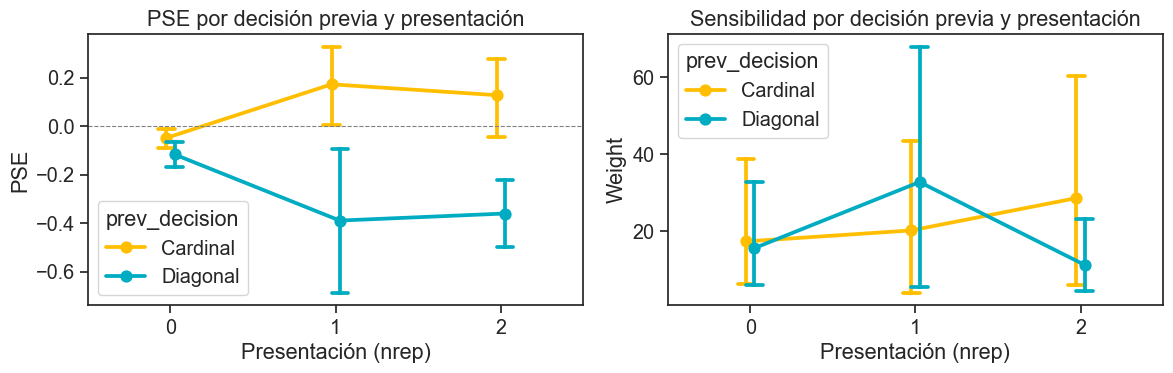

In [20]:
# Si hay confirmation bias, el PSE será más negativo cuando deci-1=Cardinal
# y más positivo cuando deci-1=Diagonal → las curvas se separan
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# PSE
sns.pointplot(
    data=log_reg_preDeci_clean,
    x='nrep',
    y='PSE',
    hue='prev_decision',
    dodge=True,
    capsize=0.1,
    palette=['#ffbf00', '#00acc1'],
    ax=axes[0]
)
axes[0].set_title('PSE por decisión previa y presentación')
axes[0].set_xlabel('Presentación (nrep)')
axes[0].set_ylabel('PSE')
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8)

# Weight
sns.pointplot(
    data=log_reg_preDeci,
    x='nrep',
    y='weight',
    hue='prev_decision',
    dodge=True,
    capsize=0.1,
    palette=['#ffbf00', '#00acc1'],
    ax=axes[1]
)
axes[1].set_title('Sensibilidad por decisión previa y presentación')
axes[1].set_xlabel('Presentación (nrep)')
axes[1].set_ylabel('Weight')

plt.tight_layout()
plt.show()

In [21]:
# Solo tiene sentido para nrep > 0 (en nrep=0 no hay decisión previa dentro del trial)
dat = log_reg_preDeci[log_reg_preDeci['nrep'] > 0]

print('ANOVA — PSE condicionado a decisión previa:')
print(pg.rm_anova(
    dv='PSE',
    within=['nrep', 'deci-1'],
    subject='subj',
    data=dat,
    detailed=True,
    correction=True
))

print('\nANOVA — Weight condicionado a decisión previa:')
print(pg.rm_anova(
    dv='weight',
    within=['nrep', 'deci-1'],
    subject='subj',
    data=dat,
    detailed=True,
    correction=True
))

ANOVA — PSE condicionado a decisión previa:
          Source   SS  ddof1  ddof2   MS   F  p_unc  p_GG_corr  ng2  eps
0           nrep  inf      1     24  inf NaN    NaN        NaN  NaN  1.0
1         deci-1  inf      1     24  inf NaN    NaN        NaN  NaN  1.0
2  nrep * deci-1  NaN      1     24  NaN NaN    NaN        NaN  NaN  1.0

ANOVA — Weight condicionado a decisión previa:
          Source           SS  ddof1  ddof2           MS         F     p_unc  \
0           nrep  1082.696194      1     24  1082.696194  0.264030  0.612064   
1         deci-1   144.389315      1     24   144.389315  0.033755  0.855772   
2  nrep * deci-1  5621.151440      1     24  5621.151440  1.485239  0.234801   

   p_GG_corr       ng2  eps  
0   0.612064  0.003027  1.0  
1   0.855772  0.000405  1.0  
2   0.234801  0.015517  1.0  


/opt/anaconda3/envs/SINTESI/lib/python3.10/site-packages/pingouin/parametric.py:722: RuntimeWarning: invalid value encountered in scalar subtract
  ss_ab = ss_ab_er - ss_a - ss_b
/opt/anaconda3/envs/SINTESI/lib/python3.10/site-packages/pingouin/parametric.py:724: RuntimeWarning: invalid value encountered in scalar subtract
  ss_as = ss_as_er - ss_s - ss_a
/opt/anaconda3/envs/SINTESI/lib/python3.10/site-packages/pingouin/parametric.py:726: RuntimeWarning: invalid value encountered in scalar subtract
  ss_bs = ss_bs_er - ss_s - ss_b
/opt/anaconda3/envs/SINTESI/lib/python3.10/site-packages/pingouin/parametric.py:727: RuntimeWarning: invalid value encountered in scalar subtract
  ss_abs = ss_tot - ss_a - ss_b - ss_s - ss_ab - ss_as - ss_bs
/opt/anaconda3/envs/SINTESI/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2888: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]
/opt/anaconda3/envs/SINTESI/lib/python3.10/site-packages/numpy/lib/_function_base_im

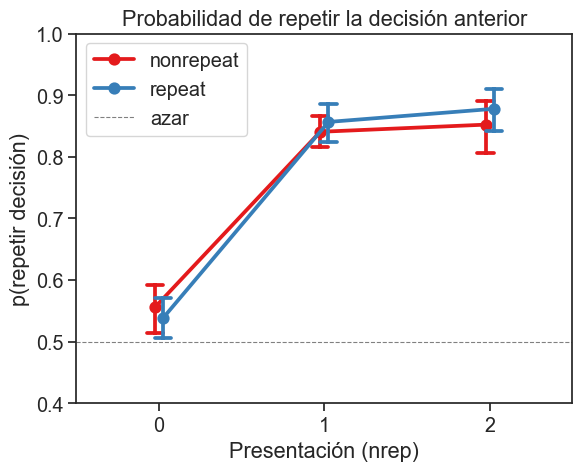


Media de p(repetir) por nrep:
nrep
0    0.547
1    0.849
2    0.865
Name: p_repeat, dtype: float64


In [22]:
# Calculamos directamente p(repetir decisión) por participante, nrep y trial_type
# switch=0 significa que repitió → p(repetir) = 1 - mean(switch)
avg_switch = df_rt.groupby(
    ['subj', 'nrep', 'trial_type'], as_index=False
)[['switch']].mean()

avg_switch['p_repeat'] = 1 - avg_switch['switch']

sns.pointplot(
    data=avg_switch,
    x='nrep',
    y='p_repeat',
    hue='trial_type',
    dodge=True,
    capsize=0.1,
    palette='Set1'
)
plt.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='azar')
plt.xlabel('Presentación (nrep)')
plt.ylabel('p(repetir decisión)')
plt.title('Probabilidad de repetir la decisión anterior')
plt.ylim(0.4, 1.0)
plt.legend()
plt.show()

print('\nMedia de p(repetir) por nrep:')
print(avg_switch.groupby('nrep')['p_repeat'].mean().round(3))

In [25]:
# Crear confi-1 ANTES del filtro de RT, sobre df completo
df = df.sort_values(['subj', 'nblock', 'ntrial', 'nrep']).reset_index(drop=True)

df['confi-1'] = df.groupby(['subj', 'nblock', 'ntrial'])['confi'].shift(1)

# Verificación
print('Ejemplo trial completo:')
print(df[df['subj'] == 'S03'][['subj','nblock','ntrial','nrep','confi','confi-1']].head(9))
print(f'\nNaN en confi-1: {df["confi-1"].isna().sum()} (esperado ≈ nº trials, uno por nrep=0)')

Ejemplo trial completo:
  subj  nblock  ntrial  nrep  confi  confi-1
0  S03       0       0     0  -0.25      NaN
1  S03       0       0     1  -0.05    -0.25
2  S03       0       0     2   1.00    -0.05
3  S03       0       1     0   0.25      NaN
4  S03       0       1     1  -0.45     0.25
5  S03       0       1     2   0.10    -0.45
6  S03       0       2     0   0.75      NaN
7  S03       0       2     1  -0.05     0.75
8  S03       0       2     2  -0.35    -0.05

NaN en confi-1: 2200 (esperado ≈ nº trials, uno por nrep=0)


In [28]:
# Para cada nrep, testamos si la probabilidad de repetir es mayor que el azar (0.5)
# Usamos un t-test de una muestra contra 0.5
print('Test t contra 0.5 (azar) por nrep:\n')
for nrep_val in [0, 1, 2]:
    dat = avg_switch[avg_switch['nrep'] == nrep_val]['p_repeat']
    t, p = stats.ttest_1samp(dat, 0.5)
    print(f'nrep={nrep_val}: t={t:.3f}, p={p:.4f} → '
          f'{"SIGNIFICATIVO ✓" if p < 0.05 else "no significativo"}')

Test t contra 0.5 (azar) por nrep:

nrep=0: t=3.544, p=0.0009 → SIGNIFICATIVO ✓
nrep=1: t=32.404, p=0.0000 → SIGNIFICATIVO ✓
nrep=2: t=25.912, p=0.0000 → SIGNIFICATIVO ✓


In [29]:
# Filtramos nrep > 0 porque nrep=0 no tiene trial anterior
df_meta = df_rt[df_rt['nrep'] > 0].copy()

# Media por participante de confi-1 y correct
avg_subj = df_meta.groupby('subj', as_index=False)[['confi-1', 'correct']].mean()

# Scatter: confianza previa vs precisión actual por participante
fig, ax = plt.subplots(figsize=(6, 5))
sns.regplot(
    data=avg_subj,
    x='confi-1', y='correct',
    scatter_kws={'s': 60},
    line_kws={'color': 'red'},
    ax=ax
)
ax.set_title('Confianza previa vs Precisión actual (por participante)')
ax.set_xlabel('Confianza media (trial anterior)')
ax.set_ylabel('p(correct)')
plt.tight_layout()
plt.show()

# Correlación estadística
corr = pg.corr(avg_subj['confi-1'], avg_subj['correct'], method='pearson')
print('Correlación confianza previa ~ precisión actual:')
print(corr.round(3))

KeyError: "Columns not found: 'confi-1'"

In [ ]:
# Crear confi-1 ANTES del filtro de RT, sobre df completo
df = df.sort_values(['subj', 'nblock', 'ntrial', 'nrep']).reset_index(drop=True)

df['confi-1'] = df.groupby(['subj', 'nblock', 'ntrial'])['confi'].shift(1)

# Verificación
print('Ejemplo trial completo:')
print(df[df['subj'] == 'S03'][['subj','nblock','ntrial','nrep','confi','confi-1']].head(9))
print(f'\nNaN en confi-1: {df["confi-1"].isna().sum()} (esperado ≈ nº trials, uno por nrep=0)')

Ejemplo trial completo:
  subj  nblock  ntrial  nrep  confi  confi-1
0  S03       0       0     0  -0.25      NaN
1  S03       0       0     1  -0.05    -0.25
2  S03       0       0     2   1.00    -0.05
3  S03       0       1     0   0.25      NaN
4  S03       0       1     1  -0.45     0.25
5  S03       0       1     2   0.10    -0.45
6  S03       0       2     0   0.75      NaN
7  S03       0       2     1  -0.05     0.75
8  S03       0       2     2  -0.35    -0.05

NaN en confi-1: 2200 (esperado ≈ nº trials, uno por nrep=0)


In [ ]:
# Re-aplicar filtro de RT ahora que df tiene confi-1
df_rt = df.groupby(['npar'], group_keys=False).apply(RT_filter, sd=4)
df_rt = df_rt.reset_index(drop=True)
print(f'df_rt listo: {df_rt.shape[0]} filas')
print(f'NaN en confi-1 en df_rt: {df_rt["confi-1"].isna().sum()}')

df_rt listo: 6537 filas
NaN en confi-1 en df_rt: 2167


/var/folders/6t/135j38t15hx5h_82vyspq6pm0000gn/T/ipykernel_830/2166842916.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_rt = df.groupby(['npar'], group_keys=False).apply(RT_filter, sd=4)


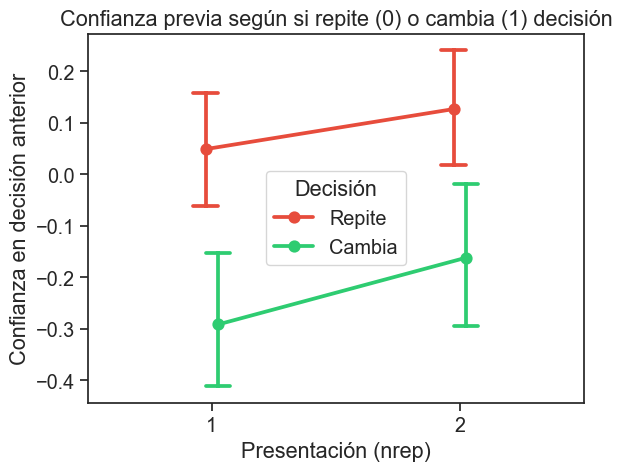

In [ ]:
# ¿Los participantes son más confiados cuando repiten que cuando cambian?
# Si es así, la confianza previa predice el sesgo de repetición
avg_confi_switch = df_rt.groupby(
    ['subj', 'nrep', 'switch', 'trial_type'], as_index=False
)[['confi', 'confi-1']].mean()

sns.pointplot(
    data=avg_confi_switch[avg_confi_switch['nrep'] > 0],
    x='nrep', y='confi-1',
    hue='switch',
    dodge=True, capsize=0.1,
    palette={0: '#e74c3c', 1: '#2ecc71'}
)
plt.title('Confianza previa según si repite (0) o cambia (1) decisión')
plt.xlabel('Presentación (nrep)')
plt.ylabel('Confianza en decisión anterior')
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Repite', 'Cambia'], title='Decisión')
plt.show()

Participantes con metad disponible: 24
Media metad: 0.628
Std  metad: 0.317
Rango: [0.086, 1.226]


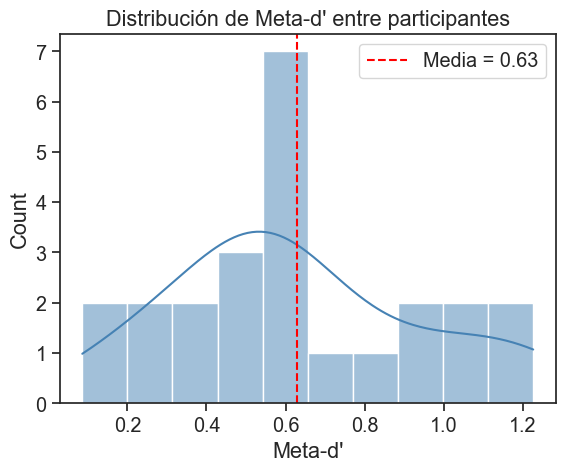

In [ ]:
# metad ya está calculado en el CSV (un valor único por participante)
# Lo extraemos a nivel de participante
metad_subj = df_rt.groupby('subj', as_index=False)['metad'].first()
metad_subj = metad_subj.dropna()  # eliminamos los que no tienen metad

print(f'Participantes con metad disponible: {len(metad_subj)}')
print(f'Media metad: {metad_subj["metad"].mean():.3f}')
print(f'Std  metad: {metad_subj["metad"].std():.3f}')
print(f'Rango: [{metad_subj["metad"].min():.3f}, {metad_subj["metad"].max():.3f}]')

# Distribución de metad entre participantes
sns.histplot(data=metad_subj, x='metad', kde=True, bins=10, color='steelblue')
plt.axvline(metad_subj['metad'].mean(), color='red',
            linestyle='--', label=f'Media = {metad_subj["metad"].mean():.2f}')
plt.title('Distribución de Meta-d\' entre participantes')
plt.xlabel('Meta-d\'')
plt.legend()
plt.show()

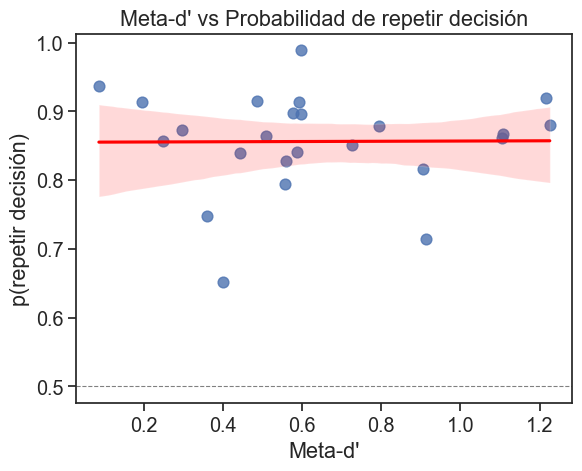

Correlación Meta-d' ~ p(repetir):
          n      r          CI95  p_val   BF10  power
pearson  24  0.007  [-0.4, 0.41]  0.973  0.253   0.05


In [ ]:
# Calculamos p(repetir) por participante (colapsado sobre nrep=1 y nrep=2)
# y la cruzamos con metad para ver si mejor metacognición → menos sesgo
avg_repeat_subj = df_rt[df_rt['nrep'] > 0].groupby(
    'subj', as_index=False
)['switch'].mean()
avg_repeat_subj['p_repeat'] = 1 - avg_repeat_subj['switch']

# Unimos con metad
avg_repeat_subj = avg_repeat_subj.merge(metad_subj, on='subj')

# Scatter: metad vs p(repetir)
sns.regplot(
    data=avg_repeat_subj,
    x='metad', y='p_repeat',
    scatter_kws={'s': 60},
    line_kws={'color': 'red'}
)
plt.title('Meta-d\' vs Probabilidad de repetir decisión')
plt.xlabel('Meta-d\'')
plt.ylabel('p(repetir decisión)')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
plt.show()

# Correlación estadística
corr_metad = pg.corr(
    avg_repeat_subj['metad'],
    avg_repeat_subj['p_repeat'],
    method='pearson'
)
print('Correlación Meta-d\' ~ p(repetir):')
print(corr_metad.round(3))

In [ ]:
def log_stimmultreg_fit(x, f):
    """
    Regresión logística multivariable con los 6 estímulos individuales.
    Añade deci-1 como regresor para controlar el efecto de la decisión previa
    y aislar el efecto sensorial puro de cada estímulo (d1-d6).
    Al incluir deci-1, el efecto de recencia en d6 se separa del CB.
    """
    try:
        reg = smf.glm(formula=f, data=x,
                      family=sm.families.Binomial()).fit(disp=0)
        params = reg.params
        out = pd.DataFrame([[
            params.get('Intercept',      np.nan),
            params.get('Q("deci-1")',    np.nan),  # regresor nuevo: decisión previa
            params.get('d1',             np.nan),
            params.get('d2',             np.nan),
            params.get('d3',             np.nan),
            params.get('d4',             np.nan),
            params.get('d5',             np.nan),
            params.get('d6',             np.nan),
        ]], columns=['intercept', 'prev_deci',
                     'G1ori', 'G2ori', 'G3ori',
                     'G4ori', 'G5ori', 'G6ori'])
        return out
    except Exception:
        return pd.DataFrame([[np.nan]*8],
                            columns=['intercept', 'prev_deci',
                                     'G1ori', 'G2ori', 'G3ori',
                                     'G4ori', 'G5ori', 'G6ori'])

# Fórmula actualizada: añadimos Q('deci-1') como regresor de control
# Solo tiene sentido para nrep > 0 donde hay decisión previa disponible
formula = 'deci ~ Q("deci-1") + d1 + d2 + d3 + d4 + d5 + d6'

df_mr_betas = df_rt[df_rt['nrep'] > 0].groupby(['subj', 'nrep']).apply(
    log_stimmultreg_fit, formula
)
df_mr_betas.reset_index(inplace=True)
df_mr_betas.drop(columns='level_2', errors='ignore', inplace=True)

print('Parámetros estimados (con deci-1 como control):')
print(df_mr_betas.head(6))
print(f'\nMedia del coeficiente deci-1: {df_mr_betas["prev_deci"].mean():.3f}')

/opt/anaconda3/envs/SINTESI/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/anaconda3/envs/SINTESI/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/anaconda3/envs/SINTESI/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/anaconda3/envs/SINTESI/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be

Parámetros estimados (con deci-1 como control):
  subj  nrep  intercept  prev_deci     G1ori     G2ori     G3ori     G4ori  \
0  S03     1  -0.738072   2.384295  1.826190  0.885497  1.704319  0.642490   
1  S03     2   0.298415   1.281847  0.103004  0.271016  0.671488  1.566413   
2  s01     1  -6.145762  13.234472  4.584388  1.147548 -0.040511  0.260274   
3  s01     2  -1.808979   4.937182  3.421835  0.627369  0.907062  1.710324   
4  s04     1  -3.029982   6.096299  2.720048  2.557281  1.485334  2.417133   
5  s04     2  -1.408128   4.986310  1.942714  0.733209  2.110528  1.713245   

      G5ori     G6ori  
0  0.607304  1.436716  
1  0.802908  1.319533  
2  7.240296  0.499851  
3  1.901292  0.932104  
4  1.354409  1.245702  
5  0.597878 -0.403805  

Media del coeficiente deci-1: 7.003


/var/folders/6t/135j38t15hx5h_82vyspq6pm0000gn/T/ipykernel_830/10105173.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_mr_betas = df_rt[df_rt['nrep'] > 0].groupby(['subj', 'nrep']).apply(


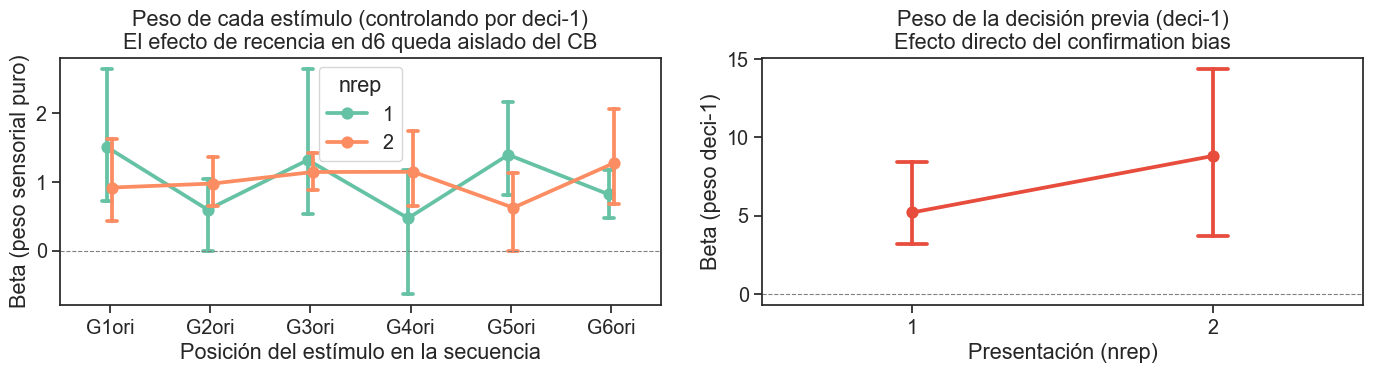

Test t del peso de deci-1 contra 0:
  nrep=1: t=3.592, p=0.0015 → SIGNIFICATIVO ✓
  nrep=2: t=3.025, p=0.0058 → SIGNIFICATIVO ✓


In [ ]:
# Pasamos a formato largo para plotear — ahora incluye prev_deci
df_betas = pd.melt(
    df_mr_betas,
    id_vars=['subj', 'nrep'],
    value_vars=['G1ori', 'G2ori', 'G3ori', 'G4ori', 'G5ori', 'G6ori']
)
df_betas.rename(columns={'variable': 'parameter', 'value': 'value'},
                inplace=True)
df_betas = df_betas.dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Gráfico 1: pesos de d1-d6 controlando por deci-1
sns.pointplot(
    data=df_betas,
    x='parameter', y='value',
    hue='nrep',
    dodge=True, capsize=0.1,
    palette='Set2',
    ax=axes[0]
)
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[0].set_title('Peso de cada estímulo (controlando por deci-1)\n'
                  'El efecto de recencia en d6 queda aislado del CB')
axes[0].set_xlabel('Posición del estímulo en la secuencia')
axes[0].set_ylabel('Beta (peso sensorial puro)')

# Gráfico 2: peso de la decisión previa (deci-1)
sns.pointplot(
    data=df_mr_betas,
    x='nrep', y='prev_deci',
    capsize=0.1,
    color='#e74c3c',
    ax=axes[1]
)
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[1].set_title('Peso de la decisión previa (deci-1)\n'
                  'Efecto directo del confirmation bias')
axes[1].set_xlabel('Presentación (nrep)')
axes[1].set_ylabel('Beta (peso deci-1)')

plt.tight_layout()
plt.show()

# Test estadístico: ¿el peso de deci-1 es significativamente > 0?
print('Test t del peso de deci-1 contra 0:')
for nrep_val in [1, 2]:
    dat = df_mr_betas[df_mr_betas['nrep'] == nrep_val]['prev_deci'].dropna()
    t, p = stats.ttest_1samp(dat, 0)
    print(f'  nrep={nrep_val}: t={t:.3f}, p={p:.4f} → '
          f'{"SIGNIFICATIVO ✓" if p < 0.05 else "no significativo"}')

In [ ]:
# Para cada trial, calculamos la diferencia entre cada estímulo y la decisión previa
# Un valor positivo = congruente con decisión previa diagonal
# Un valor negativo = incongruente (favorece cardinal)

# deci-1 recodificada: 1=diagonal, -1=cardinal
prev_deci = df_rt['deci-1'].copy()
prev_deci[prev_deci == 0] = -1  # cardinal → -1

# Diferencia entre cada estímulo y la decisión previa
# Cuanto más positivo, más congruente con decisión previa
diff1 = df_rt['d1'] * prev_deci
diff2 = df_rt['d2'] * prev_deci
diff3 = df_rt['d3'] * prev_deci
diff4 = df_rt['d4'] * prev_deci
diff5 = df_rt['d5'] * prev_deci
diff6 = df_rt['d6'] * prev_deci

# Matriz de diferencias (ntrials x 6)
prev_respdiff = np.column_stack([diff1, diff2, diff3, diff4, diff5, diff6])

# Ordenamos de más congruente (mayor diff) a más incongruente (menor diff)
sort_idx = prev_respdiff.argsort(axis=1)[:, ::-1]  # descendente

# Reordenamos los estímulos originales según congruencia
orientations = df_rt[['d1', 'd2', 'd3', 'd4', 'd5', 'd6']].values
reo_orientations = np.take_along_axis(orientations, sort_idx, axis=1)
reo_df = pd.DataFrame(
    reo_orientations,
    columns=['G1sim', 'G2sim', 'G3sim', 'G4sim', 'G5sim', 'G6sim']
)

# Añadimos al dataframe
df_glm = pd.concat([df_rt.reset_index(drop=True), reo_df], axis=1)
df_glm['deci_prev'] = prev_deci.values

print('Columnas nuevas añadidas:', ['G1sim','G2sim','G3sim','G4sim','G5sim','G6sim','deci_prev'])
print(df_glm[['subj','nrep','deci-1','deci_prev','G1sim','G6sim']].head(6))

Columnas nuevas añadidas: ['G1sim', 'G2sim', 'G3sim', 'G4sim', 'G5sim', 'G6sim', 'deci_prev']
  subj  nrep  deci-1  deci_prev     G1sim     G6sim
0  s01     0       0         -1 -0.986749  0.820733
1  s01     1       0         -1 -0.986749  0.820733
2  s01     2       0         -1 -0.986749  0.820733
3  s01     0       0         -1 -0.734648  0.711234
4  s01     1       1          1  0.711234 -0.734648
5  s01     2       1          1  0.711234 -0.734648


In [ ]:
# Añadimos deci_prev como regresor de control también en el análisis
# de estímulos ordenados por congruencia
formula_sim = 'deci ~ deci_prev + G1sim + G2sim + G3sim + G4sim + G5sim + G6sim'

def log_sim_fit(x, f):
    try:
        reg = smf.glm(formula=f, data=x,
                      family=sm.families.Binomial()).fit(disp=0)
        params = reg.params
        out = pd.DataFrame([[
            params.get('Intercept', np.nan),
            params.get('deci_prev', np.nan),
            params.get('G1sim',     np.nan),
            params.get('G2sim',     np.nan),
            params.get('G3sim',     np.nan),
            params.get('G4sim',     np.nan),
            params.get('G5sim',     np.nan),
            params.get('G6sim',     np.nan),
        ]], columns=['intercept', 'prev_deci',
                     'G1sim', 'G2sim', 'G3sim',
                     'G4sim', 'G5sim', 'G6sim'])
        return out
    except Exception:
        return pd.DataFrame([[np.nan]*8],
                            columns=['intercept', 'prev_deci',
                                     'G1sim', 'G2sim', 'G3sim',
                                     'G4sim', 'G5sim', 'G6sim'])

df_sim_betas = df_glm[df_glm['nrep'] > 0].groupby(['subj', 'nrep']).apply(
    log_sim_fit, formula_sim
)
df_sim_betas.reset_index(inplace=True)
df_sim_betas.drop(columns='level_2', errors='ignore', inplace=True)
print(df_sim_betas.head(6))

/opt/anaconda3/envs/SINTESI/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/anaconda3/envs/SINTESI/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/anaconda3/envs/SINTESI/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/anaconda3/envs/SINTESI/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be

  subj  nrep  intercept  prev_deci     G1sim     G2sim     G3sim     G4sim  \
0  S03     1   0.300932   2.230141 -1.408339  1.286984  3.359336  0.638117   
1  S03     2   1.160369   1.488069  2.795910  2.252128 -2.631116  1.142322   
2  s01     1   0.329543   3.219781  4.011892 -6.896110  6.577919  5.798675   
3  s01     2   1.204043  -1.034313  9.208156  7.223175 -4.140039  0.771403   
4  s04     1   0.080674   5.215365  5.143534  0.348171  3.011508  0.788173   
5  s04     2   0.246348   0.674926  4.234431 -4.738778  2.183960  1.370933   

      G5sim     G6sim  
0 -0.291859  1.425109  
1  1.366202  3.722253  
2  0.460791 -1.626775  
3  1.443764  5.596251  
4  1.214451  7.177763  
5  4.227988 -3.865364  


/var/folders/6t/135j38t15hx5h_82vyspq6pm0000gn/T/ipykernel_830/2899961481.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sim_betas = df_glm[df_glm['nrep'] > 0].groupby(['subj', 'nrep']).apply(


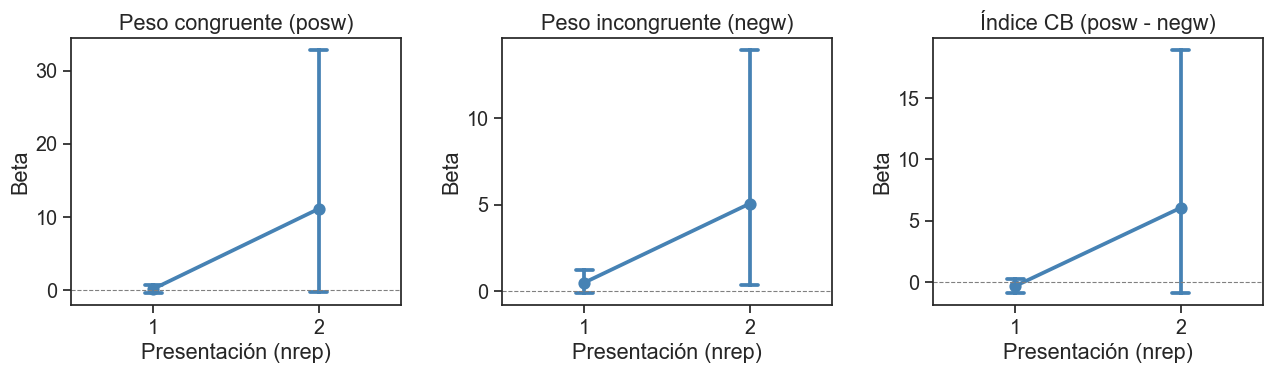

Test t del índice CB contra 0:

nrep=1: t=-1.199, p=0.2424 → no significativo
nrep=2: t=0.981, p=0.3366 → no significativo


In [ ]:
# El índice de CB es la diferencia entre el peso de los estímulos
# más congruentes (G1sim, G2sim) y los más incongruentes (G5sim, G6sim)
# CB > 0 → los estímulos congruentes pesan más → confirmation bias

df_sim_betas['posw'] = (df_sim_betas['G1sim'] + df_sim_betas['G2sim']) / 2
df_sim_betas['negw'] = (df_sim_betas['G5sim'] + df_sim_betas['G6sim']) / 2
df_sim_betas['cbias_idx'] = df_sim_betas['posw'] - df_sim_betas['negw']

# Visualizar
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, col, title in zip(axes,
                           ['posw', 'negw', 'cbias_idx'],
                           ['Peso congruente (posw)',
                            'Peso incongruente (negw)',
                            'Índice CB (posw - negw)']):
    sns.pointplot(
        data=df_sim_betas,
        x='nrep', y=col,
        capsize=0.1, color='steelblue', ax=ax
    )
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel('Presentación (nrep)')
    ax.set_ylabel('Beta')

plt.tight_layout()
plt.show()

# ¿El índice de CB es significativamente mayor que 0?
print('Test t del índice CB contra 0:\n')
for nrep_val in [1, 2]:
    dat = df_sim_betas[df_sim_betas['nrep'] == nrep_val]['cbias_idx'].dropna()
    t, p = stats.ttest_1samp(dat, 0)
    print(f'nrep={nrep_val}: t={t:.3f}, p={p:.4f} → '
          f'{"SIGNIFICATIVO ✓" if p < 0.05 else "no significativo"}')

Filas originales : 50
Filas tras filtro: 49
Eliminadas       : 1


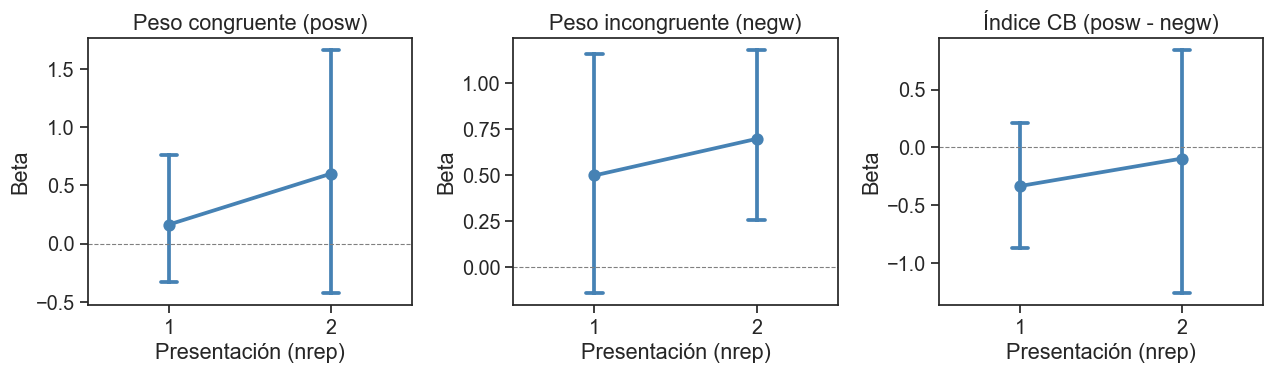

Test t del índice CB contra 0 (tras filtro):

nrep=1: t=-1.199, p=0.2424 → no significativo
nrep=2: t=-0.170, p=0.8666 → no significativo


In [ ]:
# Filtrar OUTLIERS !!!!! 

cbias_limit = 20  # límite razonable

df_sim_betas_clean = df_sim_betas[
    np.abs(df_sim_betas['cbias_idx']) < cbias_limit
].copy()

print(f'Filas originales : {len(df_sim_betas)}')
print(f'Filas tras filtro: {len(df_sim_betas_clean)}')
print(f'Eliminadas       : {len(df_sim_betas) - len(df_sim_betas_clean)}')

# Re-visualizar
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col, title in zip(axes,
                           ['posw', 'negw', 'cbias_idx'],
                           ['Peso congruente (posw)',
                            'Peso incongruente (negw)',
                            'Índice CB (posw - negw)']):
    sns.pointplot(
        data=df_sim_betas_clean,
        x='nrep', y=col,
        capsize=0.1, color='steelblue', ax=ax
    )
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel('Presentación (nrep)')
    ax.set_ylabel('Beta')

plt.tight_layout()
plt.show()

# Re-tests
print('Test t del índice CB contra 0 (tras filtro):\n')
for nrep_val in [1, 2]:
    dat = df_sim_betas_clean[
        df_sim_betas_clean['nrep'] == nrep_val
    ]['cbias_idx'].dropna()
    t, p = stats.ttest_1samp(dat, 0)
    print(f'nrep={nrep_val}: t={t:.3f}, p={p:.4f} → '
          f'{"SIGNIFICATIVO ✓" if p < 0.05 else "no significativo"}')

In [ ]:
print(df_rt.columns.tolist())
print(df_rt[['subj', 'nrep', 'correct', 'correct-1', 'metad']].head(10))
print(f"\nValores únicos correct-1: {df_rt['correct-1'].unique()}")
print(f"NaN en correct-1: {df_rt['correct-1'].isna().sum()}")

['exp_ID', 'npar', 'subj', 'nblock', 'ntrial', 'nrep', 'cond-1', 'trial_type', 'rDV', 'deci-3', 'deci-2', 'deci-1', 'cond', 'deci', 'DV', 'resp', 'corr-1', 'r_map', 'correct', 'confi', 'RT', 'd1', 'd2', 'd3', 'd4', 'd5', 'd6', 'o1', 'o2', 'o3', 'o4', 'o5', 'o6', 'metad', 'metad_3%', 'metad_97%', 'switch', 'conf_lvl', 'confi-1', 'correct-1']
  subj  nrep  correct  correct-1  metad
0  s01     0        1          0  0.086
1  s01     1        1          1  0.086
2  s01     2        1          1  0.086
3  s01     0        0          1  0.086
4  s01     1        0          0  0.086
5  s01     2        0          0  0.086
6  s01     0        1          0  0.086
7  s01     1        1          1  0.086
8  s01     2        1          1  0.086
9  s01     0        1          1  0.086

Valores únicos correct-1: [0 1]
NaN en correct-1: 0


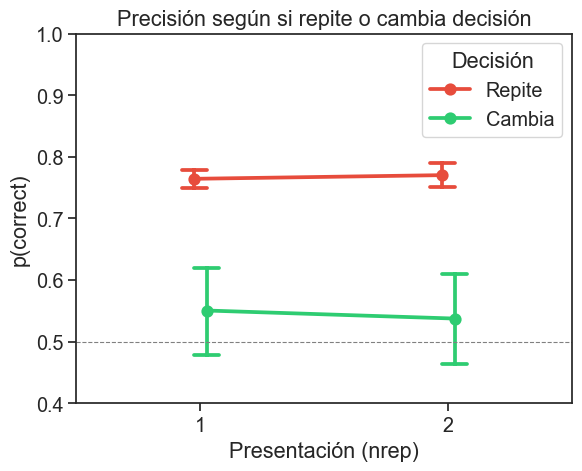

In [ ]:
# ¿Los participantes que cambian de decisión mejoran su precisión?
avg_correct_switch = df_rt.groupby(
    ['subj', 'nrep', 'switch', 'trial_type'], as_index=False
)[['correct']].mean()

# Solo nrep > 0 (donde tiene sentido hablar de switch)
sns.pointplot(
    data=avg_correct_switch[avg_correct_switch['nrep'] > 0],
    x='nrep', y='correct',
    hue='switch',
    dodge=True, capsize=0.1,
    palette={0: '#e74c3c', 1: '#2ecc71'}
)
plt.title('Precisión según si repite o cambia decisión')
plt.xlabel('Presentación (nrep)')
plt.ylabel('p(correct)')
plt.ylim(0.4, 1.0)
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Repite', 'Cambia'], title='Decisión')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
plt.show()

In [ ]:
dat = avg_correct_switch[avg_correct_switch['nrep'] > 0].copy()
dat['switch'] = dat['switch'].astype(str)  # para que pingouin lo trate como factor

print('ANOVA — Precisión según switch y trial_type:')
print(pg.rm_anova(
    dv='correct',
    within=['switch', 'trial_type'],
    subject='subj',
    data=dat,
    detailed=True,
    correction=True
))

ANOVA — Precisión según switch y trial_type:
                Source        SS  ddof1  ddof2        MS           F  \
0               switch  1.249362      1     24  1.249362  173.945105   
1           trial_type  0.073427      1     24  0.073427    3.907650   
2  switch * trial_type  0.018113      1     24  0.018113    1.243144   

          p_unc     p_GG_corr       ng2  eps  
0  1.726229e-12  1.726229e-12  0.503587  1.0  
1  5.966569e-02  5.966569e-02  0.056267  1.0  
2  2.759066e-01  2.759066e-01  0.014494  1.0  


In [ ]:
# ══════════════════════════════════════════════════════════════
# ANÁLISIS: Probabilidad de estar correcto en función de
# meta-d' efficiency y si la respuesta anterior fue correcta
# Replicando el análisis del tutor
# ══════════════════════════════════════════════════════════════

import statsmodels.formula.api as smf

# Solo nrep > 0: necesitamos correct-1 (respuesta anterior del mismo trial)
df_meta = df_rt[df_rt['nrep'] > 0].copy()

# Etiqueta legible para correct-1
df_meta['prev_correct'] = df_meta['correct-1'].map(
    {1: 'Correct', 0: 'Incorrect'}
)

print(f'Trials para el análisis: {len(df_meta)}')
print(f'\nDistribución correct-1:')
print(df_meta['prev_correct'].value_counts())
print(f'\nRango metad: [{df_meta["metad"].min():.3f}, {df_meta["metad"].max():.3f}]')

Trials para el análisis: 4370

Distribución correct-1:
prev_correct
Correct      3162
Incorrect    1208
Name: count, dtype: int64

Rango metad: [0.086, 1.226]


In [ ]:
# Ajustamos un modelo de regresión logística para cada participante
# y condición (correct-1 = 0 o 1)
# Modelo: correct ~ metad (a nivel de trial)
# Pero metad es constante por participante → usamos un modelo mixto
# que estima la relación entre metad (between-subjects) y correct

# Enfoque: calculamos p(correct) media por participante y correct-1
# luego lo ploteamos en función de metad con una regresión

df_by_subj = df_meta.groupby(
    ['subj', 'prev_correct', 'metad'], as_index=False
)['correct'].mean()

df_by_subj.rename(columns={'correct': 'p_correct'}, inplace=True)

print('Dataset por participante y condición:')
print(df_by_subj.head(8))
print(f'\nN participantes: {df_by_subj["subj"].nunique()}')

Dataset por participante y condición:
  subj prev_correct  metad  p_correct
0  S03      Correct  0.556   0.863636
1  S03    Incorrect  0.556   0.418605
2  s01      Correct  0.086   0.977099
3  s01    Incorrect  0.086   0.181818
4  s04      Correct  0.591   0.978417
5  s04    Incorrect  0.591   0.333333
6  s05      Correct  0.558   0.872000
7  s05    Incorrect  0.558   0.280000

N participantes: 24


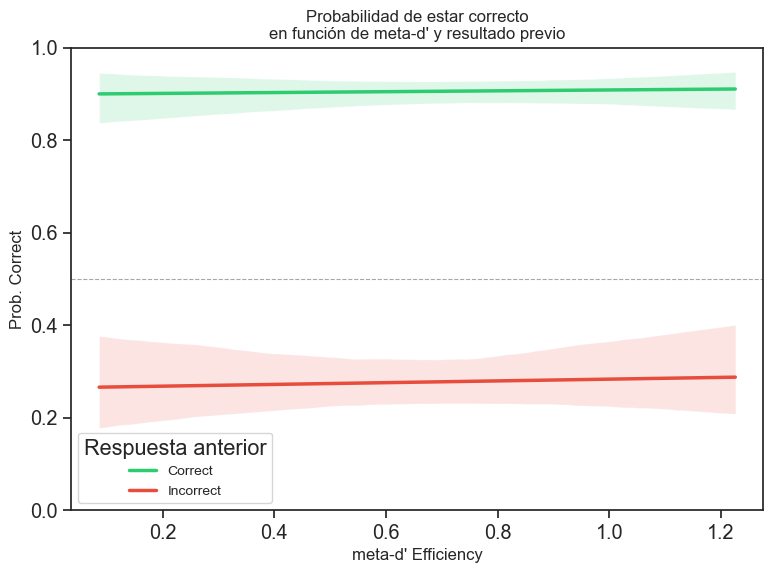

In [ ]:
# Eje X: meta-d' efficiency
# Eje Y: probabilidad de estar correcto
# Dos líneas: si la respuesta anterior fue correcta o incorrecta

fig, ax = plt.subplots(figsize=(8, 6))

colors = {'Correct': '#2ecc71', 'Incorrect': '#e74c3c'}

for prev, color in colors.items():
    d = df_by_subj[df_by_subj['prev_correct'] == prev]

    # Línea de regresión suavizada con intervalo de confianza
    # Usamos regplot de seaborn que ajusta una regresión lineal
    sns.regplot(
        data=d,
        x='metad', y='p_correct',
        color=color,
        scatter=False,          # sin puntos individuales, solo la línea
        ci=95,                  # intervalo de confianza al 95%
        label=prev,
        line_kws={'linewidth': 2.5},
        ax=ax
    )

ax.axhline(0.5, color='gray', linestyle='--',
           linewidth=0.8, alpha=0.7)
ax.set_xlabel("meta-d' Efficiency", fontsize=12)
ax.set_ylabel('Prob. Correct', fontsize=12)
ax.set_title("Probabilidad de estar correcto\n"
             "en función de meta-d' y resultado previo", fontsize=12)
ax.legend(title='Respuesta anterior', fontsize=10)
ax.set_ylim(0, 1.0)
ax.set_xlim(df_by_subj['metad'].min() - 0.05,
            df_by_subj['metad'].max() + 0.05)

plt.tight_layout()
plt.show()

In [ ]:
# Análisis estadístico: ¿la pendiente de metad es significativa
# para cada condición (correct vs incorrect)?

print('Regresión: p(correct) ~ metad por condición previa\n')
print('=' * 55)

for prev in ['Correct', 'Incorrect']:
    d = df_by_subj[df_by_subj['prev_correct'] == prev]
    model = smf.ols('p_correct ~ metad', data=d).fit()
    coef  = model.params['metad']
    pval  = model.pvalues['metad']
    r2    = model.rsquared
    sig   = '✓ Significativo' if pval < 0.05 else 'n.s.'
    print(f'Condición previa: {prev}')
    print(f'  Pendiente (beta metad): {coef:+.4f}')
    print(f'  p-valor              : {pval:.4f} → {sig}')
    print(f'  R²                   : {r2:.3f}')
    print()

print('Interpretación esperada (según tutor):')
print('  Correct   → pendiente NEGATIVA (más metad → tiende a cambiar → penaliza)')
print('  Incorrect → pendiente POSITIVA (más metad → rectifica → beneficia)')
print('  La pendiente de Incorrect debería ser más empinada (mayor efecto)')

Regresión: p(correct) ~ metad por condición previa

Condición previa: Correct
  Pendiente (beta metad): +0.0093
  p-valor              : 0.8238 → n.s.
  R²                   : 0.002

Condición previa: Incorrect
  Pendiente (beta metad): +0.0190
  p-valor              : 0.8187 → n.s.
  R²                   : 0.002

Interpretación esperada (según tutor):
  Correct   → pendiente NEGATIVA (más metad → tiende a cambiar → penaliza)
  Incorrect → pendiente POSITIVA (más metad → rectifica → beneficia)
  La pendiente de Incorrect debería ser más empinada (mayor efecto)


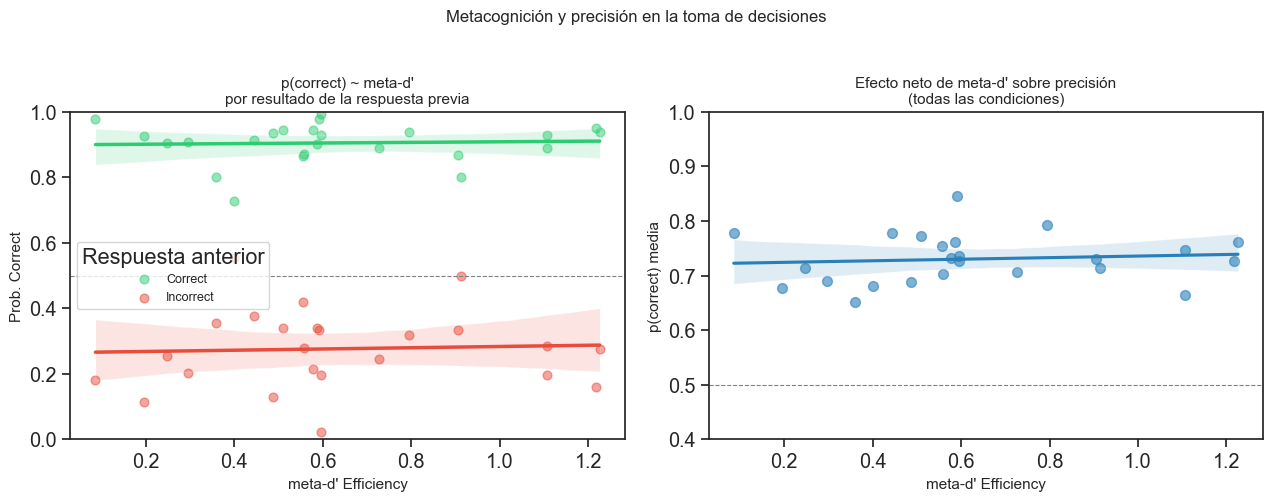

Correlación global metad ~ p(correct):
          n    r           CI95  p_val  BF10  power
pearson  24  0.1  [-0.32, 0.48]  0.642  0.28  0.075


In [ ]:
# Análisis adicional: efecto neto de metad sobre p(correct)
# Combinando ambas condiciones — ¿on average es beneficioso tener más metad?

df_overall = df_meta.groupby(
    ['subj', 'metad'], as_index=False
)['correct'].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel izquierdo: el gráfico principal del tutor
colors = {'Correct': '#2ecc71', 'Incorrect': '#e74c3c'}
for prev, color in colors.items():
    d = df_by_subj[df_by_subj['prev_correct'] == prev]
    sns.regplot(data=d, x='metad', y='p_correct',
                color=color, scatter=True, ci=95,
                label=prev, line_kws={'linewidth': 2.5},
                scatter_kws={'alpha': 0.5, 's': 40},
                ax=axes[0])
axes[0].axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
axes[0].set_xlabel("meta-d' Efficiency", fontsize=11)
axes[0].set_ylabel('Prob. Correct', fontsize=11)
axes[0].set_title("p(correct) ~ meta-d'\npor resultado de la respuesta previa",
                  fontsize=11)
axes[0].legend(title='Respuesta anterior', fontsize=9)
axes[0].set_ylim(0, 1.0)

# Panel derecho: efecto neto global
sns.regplot(data=df_overall, x='metad', y='correct',
            color='#2980b9', scatter=True, ci=95,
            scatter_kws={'alpha': 0.6, 's': 50},
            ax=axes[1])
axes[1].axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
axes[1].set_xlabel("meta-d' Efficiency", fontsize=11)
axes[1].set_ylabel('p(correct) media', fontsize=11)
axes[1].set_title("Efecto neto de meta-d' sobre precisión\n(todas las condiciones)",
                  fontsize=11)
axes[1].set_ylim(0.4, 1.0)

plt.suptitle("Metacognición y precisión en la toma de decisiones",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# Correlación global
corr = pg.corr(df_overall['metad'], df_overall['correct'], method='pearson')
print('Correlación global metad ~ p(correct):')
print(corr.round(3))

In [30]:
# ══════════════════════════════════════════════════════════════
# MODELO MIXTO: correct ~ metad * correct_prev + (1|subj)
# Usando statsmodels MixedLM (equivalente a lmer en R)
# ══════════════════════════════════════════════════════════════
from statsmodels.regression.mixed_linear_model import MixedLM

df_model = df_rt[df_rt['nrep'] > 0].copy()
df_model = df_model.rename(columns={'correct-1': 'correct_prev'})
df_model['correct_prev'] = df_model['correct_prev'].astype(float)

# Estandarizamos metad para que los coeficientes sean comparables
df_model['metad_z'] = (df_model['metad'] - df_model['metad'].mean()) / \
                       df_model['metad'].std()

# Creamos la interacción manualmente
df_model['metad_x_prev'] = df_model['metad_z'] * df_model['correct_prev']

print(f'Trials: {len(df_model)}')
print(f'Participantes: {df_model["subj"].nunique()}')
print(df_model[['subj', 'correct', 'correct_prev', 'metad_z']].head(6))

KeyError: 'correct_prev'

In [31]:
# Modelo mixto a nivel de trial
# correct ~ metad * correct-1 + (1|subj)
# metad es between-subjects (constante por participante)
# correct-1 es within-subjects (varía por trial)
# La interacción metad:correct-1 es clave — ¿depende el efecto de metad
# de si la respuesta anterior fue correcta o incorrecta?

df_model = df_rt[df_rt['nrep'] > 0].copy()

# Renombramos para evitar problemas con el guión en los nombres
df_model = df_model.rename(columns={'correct-1': 'correct_prev'})

# correct_prev como factor
df_model['correct_prev'] = df_model['correct_prev'].astype(float)

print(f'Trials en el modelo: {len(df_model)}')
print(f'Participantes: {df_model["subj"].nunique()}')
print(df_model[['subj', 'correct', 'correct_prev', 'metad']].head(8))

KeyError: 'correct_prev'

In [ ]:
# Modelo 1: efectos principales + interacción
# correct ~ metad + correct_prev + metad:correct_prev + (1|subj)

model = Lmer(
    'correct ~ metad * correct_prev + (1|subj)',
    data=df_model,
    family='binomial'
)
model.fit()
print('Modelo mixto: correct ~ metad * correct_prev + (1|subj)')
print(model.coefs)

In [ ]:
# Visualización correcta: usando las predicciones del modelo
# para cada nivel de correct_prev en función de metad

# Creamos un grid de valores de metad para predecir
metad_range = np.linspace(df_model['metad'].min(),
                          df_model['metad'].max(), 100)

fig, ax = plt.subplots(figsize=(8, 6))

colors = {1.0: '#2ecc71', 0.0: '#e74c3c'}
labels = {1.0: 'Correct', 0.0: 'Incorrect'}

for prev_val, color in colors.items():
    d = df_model[df_model['correct_prev'] == prev_val]
    sns.regplot(
        data=d,
        x='metad', y='correct',
        color=color,
        scatter=False,
        ci=95,
        logistic=True,       # regresión logística para variable binaria
        label=labels[prev_val],
        line_kws={'linewidth': 2.5},
        ax=ax
    )

ax.axhline(0.5, color='gray', linestyle='--',
           linewidth=0.8, alpha=0.7)
ax.set_xlabel("meta-d' Efficiency", fontsize=12)
ax.set_ylabel('Prob. Correct', fontsize=12)
ax.set_title("Probabilidad de estar correcto\n"
             "en función de meta-d' y resultado previo\n"
             "(regresión logística a nivel de trial)", fontsize=11)
ax.legend(title='Respuesta anterior', fontsize=10)
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.show()

In [ ]:
# Test estadístico correcto: regresión logística por condición
# a nivel de trial (sin agregar por participante)
import statsmodels.formula.api as smf

print('Regresión logística a nivel de trial por condición previa:\n')
print('=' * 60)

for prev_val, label in [(1, 'Correct'), (0, 'Incorrect')]:
    d = df_model[df_model['correct_prev'] == prev_val]
    model_glm = smf.glm(
        'correct ~ metad',
        data=d,
        family=sm.families.Binomial()
    ).fit()
    coef = model_glm.params['metad']
    pval = model_glm.pvalues['metad']
    sig  = '✓ Significativo' if pval < 0.05 else 'n.s.'
    print(f'Condición previa: {label} (n={len(d)} trials)')
    print(f'  Pendiente (beta metad): {coef:+.4f}')
    print(f'  p-valor              : {pval:.4f} → {sig}')
    print()

In [ ]:
# Creamos columna 'correct-1' como alias de 'corr-1' para compatibilidad
# con la función switch_strategy
df_rt['correct-1'] = df_rt['corr-1']
df['correct-1'] = df['corr-1']

In [ ]:
# Stubbornness = probabilidad de NO cambiar tras un error
# p(switch | error) bajo → muy terco
# Se calcula por participante y trial_type

switch_str = df_rt[df_rt['nrep'] > 0].groupby(
    ['subj', 'trial_type']
).apply(switch_strategy)

switch_str.reset_index(inplace=True)
switch_str.drop(columns='level_2', errors='ignore', inplace=True)

print(switch_str.head(6))
print(f'\nMedia stubbornness: {switch_str["stuborness"].mean():.3f}')

  subj trial_type      phit       pfa  stuborness
0  S03  nonrepeat  0.500000  0.142857    0.500000
1  S03     repeat  0.360000  0.129032    0.640000
2  s01  nonrepeat  0.285714  0.014925    0.714286
3  s01     repeat  0.086957  0.031250    0.913043
4  s04  nonrepeat  0.315789  0.014493    0.684211
5  s04     repeat  0.352941  0.028571    0.647059

Media stubbornness: 0.722


/var/folders/6t/135j38t15hx5h_82vyspq6pm0000gn/T/ipykernel_830/3574859207.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(switch_strategy)


/var/folders/6t/135j38t15hx5h_82vyspq6pm0000gn/T/ipykernel_830/793314510.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.pointplot(


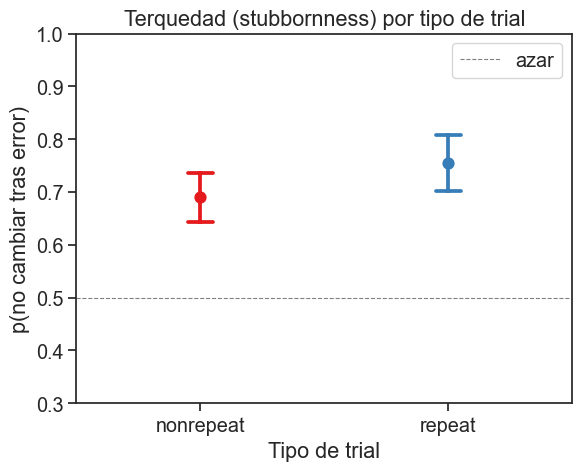

Test t stubbornness contra 0.5:

repeat: t=9.279, p=0.0000 → SIGNIFICATIVO ✓
nonrepeat: t=7.689, p=0.0000 → SIGNIFICATIVO ✓


In [ ]:
sns.pointplot(
    data=switch_str,
    x='trial_type', y='stuborness',
    capsize=0.1,
    palette='Set1'
)
plt.axhline(0.5, color='gray', linestyle='--',
            linewidth=0.8, label='azar')
plt.title('Terquedad (stubbornness) por tipo de trial')
plt.xlabel('Tipo de trial')
plt.ylabel('p(no cambiar tras error)')
plt.ylim(0.3, 1.0)
plt.legend()
plt.show()

# ¿Es significativamente mayor que 0.5?
print('Test t stubbornness contra 0.5:\n')
for tt in ['repeat', 'nonrepeat']:
    dat = switch_str[switch_str['trial_type'] == tt]['stuborness']
    t, p = stats.ttest_1samp(dat, 0.5)
    print(f'{tt}: t={t:.3f}, p={p:.4f} → '
          f'{"SIGNIFICATIVO ✓" if p < 0.05 else "no significativo"}')

/var/folders/6t/135j38t15hx5h_82vyspq6pm0000gn/T/ipykernel_830/2184307301.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(switch_strategy)


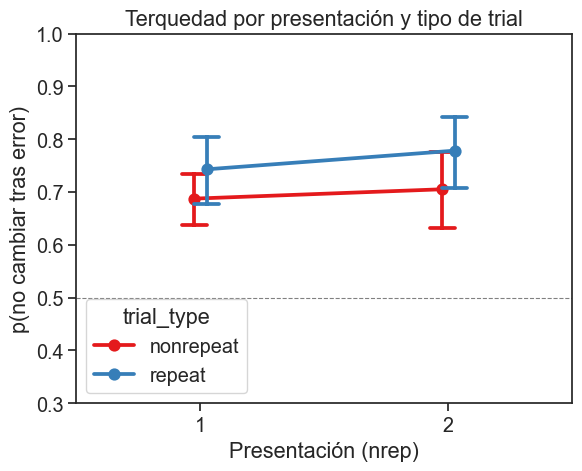

ANOVA — Stubbornness:
              Source        SS  ddof1  ddof2        MS         F     p_unc  \
0               nrep  0.017605      1     24  0.017605  0.585317  0.451694   
1         trial_type  0.103402      1     24  0.103402  8.177425  0.008641   
2  nrep * trial_type  0.001940      1     24  0.001940  0.135136  0.716387   

   p_GG_corr       ng2  eps  
0   0.451694  0.006457  1.0  
1   0.008641  0.036768  1.0  
2   0.716387  0.000715  1.0  


In [ ]:
# ¿La terquedad cambia con las repeticiones?
switch_strexp = df_rt[df_rt['nrep'] > 0].groupby(
    ['subj', 'nrep', 'trial_type']
).apply(switch_strategy)

switch_strexp.reset_index(inplace=True)
switch_strexp.drop(columns='level_3', errors='ignore', inplace=True)

sns.pointplot(
    data=switch_strexp,
    x='nrep', y='stuborness',
    hue='trial_type',
    dodge=True, capsize=0.1,
    palette='Set1'
)
plt.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
plt.title('Terquedad por presentación y tipo de trial')
plt.xlabel('Presentación (nrep)')
plt.ylabel('p(no cambiar tras error)')
plt.ylim(0.3, 1.0)
plt.show()

print('ANOVA — Stubbornness:')
print(pg.rm_anova(
    dv='stuborness',
    within=['nrep', 'trial_type'],
    subject='subj',
    data=switch_strexp,
    detailed=True,
    correction=True
))

In [ ]:
# Precisión media por participante (colapsada sobre nrep y trial_type)
avg_correct_subj = df_rt.groupby(
    ['subj', 'nrep', 'trial_type'], as_index=False
)[['correct']].mean()

# Stubbornness por participante y trial_type
switch_summary = df_rt[df_rt['nrep'] > 0].groupby(
    ['subj', 'trial_type']
).apply(switch_strategy)
switch_summary.reset_index(inplace=True)
switch_summary.drop(columns='level_2', errors='ignore', inplace=True)

# Índice de CB por participante (de df_sim_betas_clean)
cbias_summary = df_sim_betas_clean.groupby(
    ['subj'], as_index=False
)[['posw', 'negw', 'cbias_idx']].mean()

# Metad por participante
metad_summary = df_rt.groupby('subj', as_index=False)['metad'].first()

# Weight y PSE de la regresión logística básica (nrep=1, ambos trial_type)
logreg_summary = log_reg_nrep.groupby(
    ['subj'], as_index=False
)[['weight', 'PSE', 'intercept']].mean()

# p(repetir) por participante
prepeat_summary = avg_switch.groupby(
    'subj', as_index=False
)[['p_repeat']].mean()

print('Piezas del resumen:')
print(f'  avg_correct_subj : {avg_correct_subj.shape}')
print(f'  switch_summary   : {switch_summary.shape}')
print(f'  cbias_summary    : {cbias_summary.shape}')
print(f'  metad_summary    : {metad_summary.shape}')
print(f'  logreg_summary   : {logreg_summary.shape}')
print(f'  prepeat_summary  : {prepeat_summary.shape}')

Piezas del resumen:
  avg_correct_subj : (150, 4)
  switch_summary   : (50, 5)
  cbias_summary    : (25, 4)
  metad_summary    : (25, 2)
  logreg_summary   : (25, 4)
  prepeat_summary  : (25, 2)


/var/folders/6t/135j38t15hx5h_82vyspq6pm0000gn/T/ipykernel_830/3961538713.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(switch_strategy)


In [ ]:
# Unimos todo por participante
summary_df = cbias_summary.copy()
summary_df = summary_df.merge(metad_summary, on='subj', how='left')
summary_df = summary_df.merge(logreg_summary, on='subj', how='left')
summary_df = summary_df.merge(prepeat_summary, on='subj', how='left')

# Añadimos stubbornness (promediada entre repeat y nonrepeat)
stub_avg = switch_summary.groupby('subj', as_index=False)['stuborness'].mean()
summary_df = summary_df.merge(stub_avg, on='subj', how='left')

# Añadimos precisión media
correct_avg = avg_correct_subj.groupby('subj', as_index=False)['correct'].mean()
summary_df = summary_df.merge(correct_avg, on='subj', how='left')

print(f'Dataframe resumen: {summary_df.shape}')
print(summary_df.round(3))

Dataframe resumen: (25, 11)
   subj    posw   negw  cbias_idx  metad  weight    PSE  intercept  p_repeat  \
0   S03   1.982  1.136      0.845  0.556   7.244 -0.153      1.065     0.720   
1   s01   3.771  1.212      2.559  0.086   8.921 -0.088      0.729     0.822   
2   s04   1.451  0.635      0.816  0.591   6.706 -0.060      0.370     0.794   
3   s05   0.443  0.023      0.420  0.558   7.685 -0.200      1.472     0.796   
4   s07  -0.057 -1.779      1.722  0.596   7.071 -0.002      0.026     0.742   
5   s08   1.305  0.210      1.096  0.727   6.798  0.117     -0.746     0.730   
6   s09   1.409  0.126      1.283  1.107   4.554 -0.066      0.335     0.782   
7   s10  10.612  0.631      9.980  1.217   5.973  0.040     -0.260     0.789   
8   s11   0.705 -0.499      1.203  0.509   7.568 -0.060      0.552     0.766   
9   s12  -0.680 -1.319      0.639  0.487   4.845 -0.242      1.224     0.794   
10  s13   0.216 -1.290      1.506  0.794   6.324 -0.088      0.541     0.788   
11  s14   1.

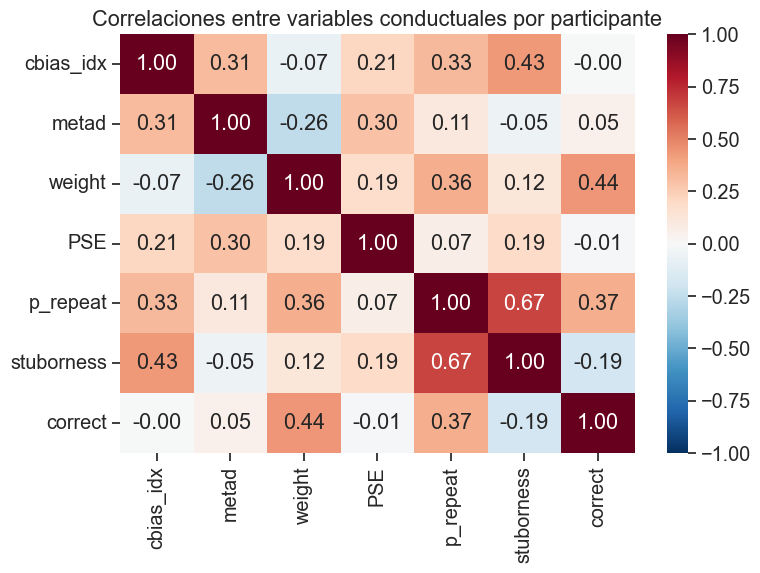

In [ ]:
# Matriz de correlaciones entre las variables principales
vars_corr = ['cbias_idx', 'metad', 'weight', 'PSE',
             'p_repeat', 'stuborness', 'correct']

corr_matrix = summary_df[vars_corr].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0,
    vmin=-1, vmax=1,
    ax=ax
)
plt.title('Correlaciones entre variables conductuales por participante')
plt.tight_layout()
plt.show()

In [ ]:
# Guardamos el dataframe resumen para usarlo en el análisis de ML
summary_df.to_csv('summary_behavioural.csv', index=False)
print('Guardado: summary_behavioural.csv')

# Guardamos también df_rt completo (limpio y con todas las variables)
# para usarlo directamente en el notebook de ML
df_rt.to_csv('CJ_EEG_clean.csv', index=False)
print('Guardado: CJ_EEG_clean.csv')

print(f'\nResumen final:')
print(f'  Participantes          : {summary_df.shape[0]}')
print(f'  Variables en resumen   : {summary_df.shape[1]}')
print(f'  Trials en dataset limpio: {df_rt.shape[0]}')
print(f'  Variables en dataset   : {df_rt.shape[1]}')

Guardado: summary_behavioural.csv
Guardado: CJ_EEG_clean.csv

Resumen final:
  Participantes          : 25
  Variables en resumen   : 11
  Trials en dataset limpio: 6537
  Variables en dataset   : 40


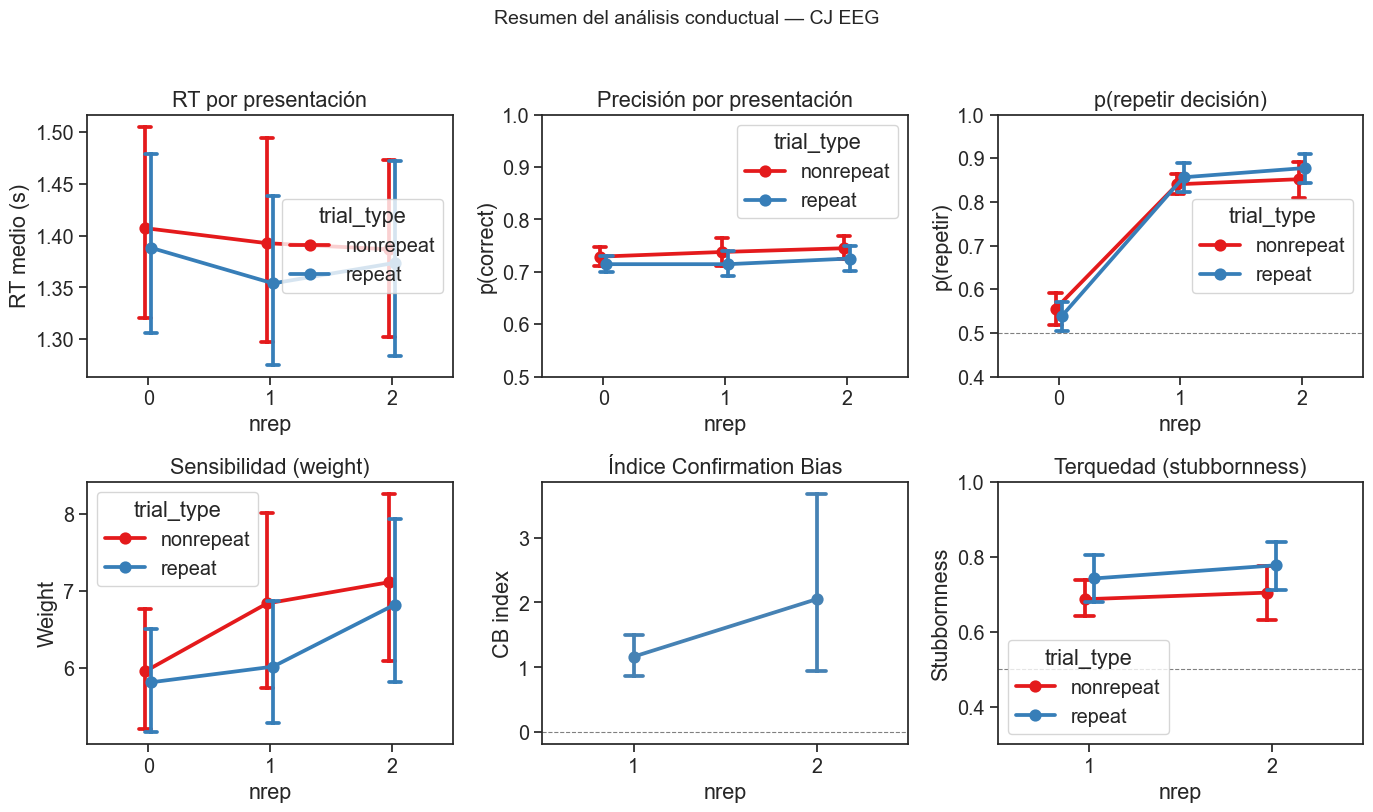

In [ ]:
# Un plot final que resume los resultados principales del análisis
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# 1. RT por nrep
sns.pointplot(data=avg_rt, x='nrep', y='RT',
              hue='trial_type', dodge=True,
              capsize=0.1, palette='Set1', ax=axes[0,0])
axes[0,0].set_title('RT por presentación')
axes[0,0].set_ylabel('RT medio (s)')

# 2. Precisión por nrep
sns.pointplot(data=avg_correct, x='nrep', y='correct',
              hue='trial_type', dodge=True,
              capsize=0.1, palette='Set1', ax=axes[0,1])
axes[0,1].set_title('Precisión por presentación')
axes[0,1].set_ylabel('p(correct)')
axes[0,1].set_ylim(0.5, 1.0)

# 3. p(repetir) por nrep
sns.pointplot(data=avg_switch, x='nrep', y='p_repeat',
              hue='trial_type', dodge=True,
              capsize=0.1, palette='Set1', ax=axes[0,2])
axes[0,2].axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
axes[0,2].set_title('p(repetir decisión)')
axes[0,2].set_ylabel('p(repetir)')
axes[0,2].set_ylim(0.4, 1.0)

# 4. Weight por nrep
sns.pointplot(data=log_reg_nrep, x='nrep', y='weight',
              hue='trial_type', dodge=True,
              capsize=0.1, palette='Set1', ax=axes[1,0])
axes[1,0].set_title('Sensibilidad (weight)')
axes[1,0].set_ylabel('Weight')

# 5. Índice CB
sns.pointplot(data=df_sim_betas_clean, x='nrep', y='cbias_idx',
              capsize=0.1, color='steelblue', ax=axes[1,1])
axes[1,1].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[1,1].set_title('Índice Confirmation Bias')
axes[1,1].set_ylabel('CB index')

# 6. Stubbornness
sns.pointplot(data=switch_strexp, x='nrep', y='stuborness',
              hue='trial_type', dodge=True,
              capsize=0.1, palette='Set1', ax=axes[1,2])
axes[1,2].axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
axes[1,2].set_title('Terquedad (stubbornness)')
axes[1,2].set_ylabel('Stubbornness')
axes[1,2].set_ylim(0.3, 1.0)

plt.suptitle('Resumen del análisis conductual — CJ EEG', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()